# Flood Prediction — EDA and Modeling

Kaggle **Playground Series S4E5: Regression with a Flood Prediction Dataset**. Each row scores
an area on 20 flood-risk factors (monsoon intensity, drainage, deforestation, …) and the target
is its `FloodProbability`. The metric is **R²**.

This notebook walks through:

1. What the data looks like — and the discovery that shapes everything else: in the original
   dataset the target is *exactly* `0.005 × (sum of the 20 factors)`.
2. Why that makes **row-level statistics** the right feature engineering.
3. A model comparison, and the one hyperparameter that mattered most.
4. What the saved app model learned (SHAP).
5. The leaderboard blend, and where each late submission would have ranked.

Every function used here lives in `src/flood_prediction/` — the notebook, the scripts, and the
Streamlit app all share it, so nothing is re-derived inline.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import r2_score

from flood_prediction import config, data, features, interpretability, leaderboard, model

sns.set_theme(style="whitegrid", palette=["#2c5cc5", "#e07a5f", "#81b29a", "#5b8def"])
pd.set_option("display.precision", 5)

## 1. The data

1.1 million training rows, 20 integer features, no missing values. Download instructions are in
the README (`kaggle competitions download -c playground-series-s4e5`).

In [2]:
train_df = data.load_full_train()
test_df = data.load_test()
X, y = data.split_features_target(train_df)
print(f"train: {train_df.shape}, test: {test_df.shape}")
print(f"missing values: {train_df.isna().sum().sum()}")
X.describe().T[["mean", "std", "min", "max"]]

train: (1117957, 21), test: (745305, 20)
missing values: 0


,mean,std,min,max
MonsoonIntensity,4.92145,2.05639,0.0,16.0
TopographyDrainage,4.92667,2.09388,0.0,18.0
RiverManagement,4.95532,2.07219,0.0,16.0
Deforestation,4.94224,2.05169,0.0,17.0
Urbanization,4.94252,2.08339,0.0,17.0
ClimateChange,4.93409,2.05774,0.0,17.0
DamsQuality,4.95588,2.08306,0.0,16.0
Siltation,4.92779,2.06599,0.0,16.0
AgriculturalPractices,4.94262,2.06855,0.0,16.0
Encroachments,4.94923,2.08332,0.0,18.0


### The target only takes 83 values

Every `FloodProbability` is a multiple of 0.005 — a strong hint that it was *computed*, not measured.

distinct target values: 83
all multiples of 0.005: True


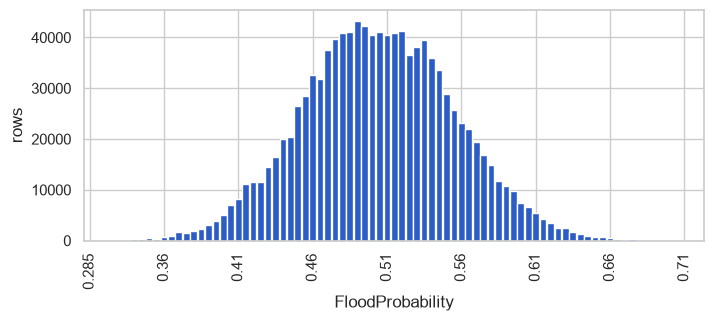

In [3]:
print(f"distinct target values: {y.nunique()}")
print(f"all multiples of 0.005: {np.allclose(np.round(y / 0.005) * 0.005, y)}")
fig, ax = plt.subplots(figsize=(8, 3))
y.value_counts().sort_index().plot.bar(ax=ax, width=0.9)
ax.set_xticks(ax.get_xticks()[::10])
ax.set_xlabel("FloodProbability")
ax.set_ylabel("rows")
plt.show()

### Every feature looks alike

All 20 factors are right-skewed integer distributions centred near 5 with nearly identical shapes,
and train and test match (orange overlays blue almost exactly).

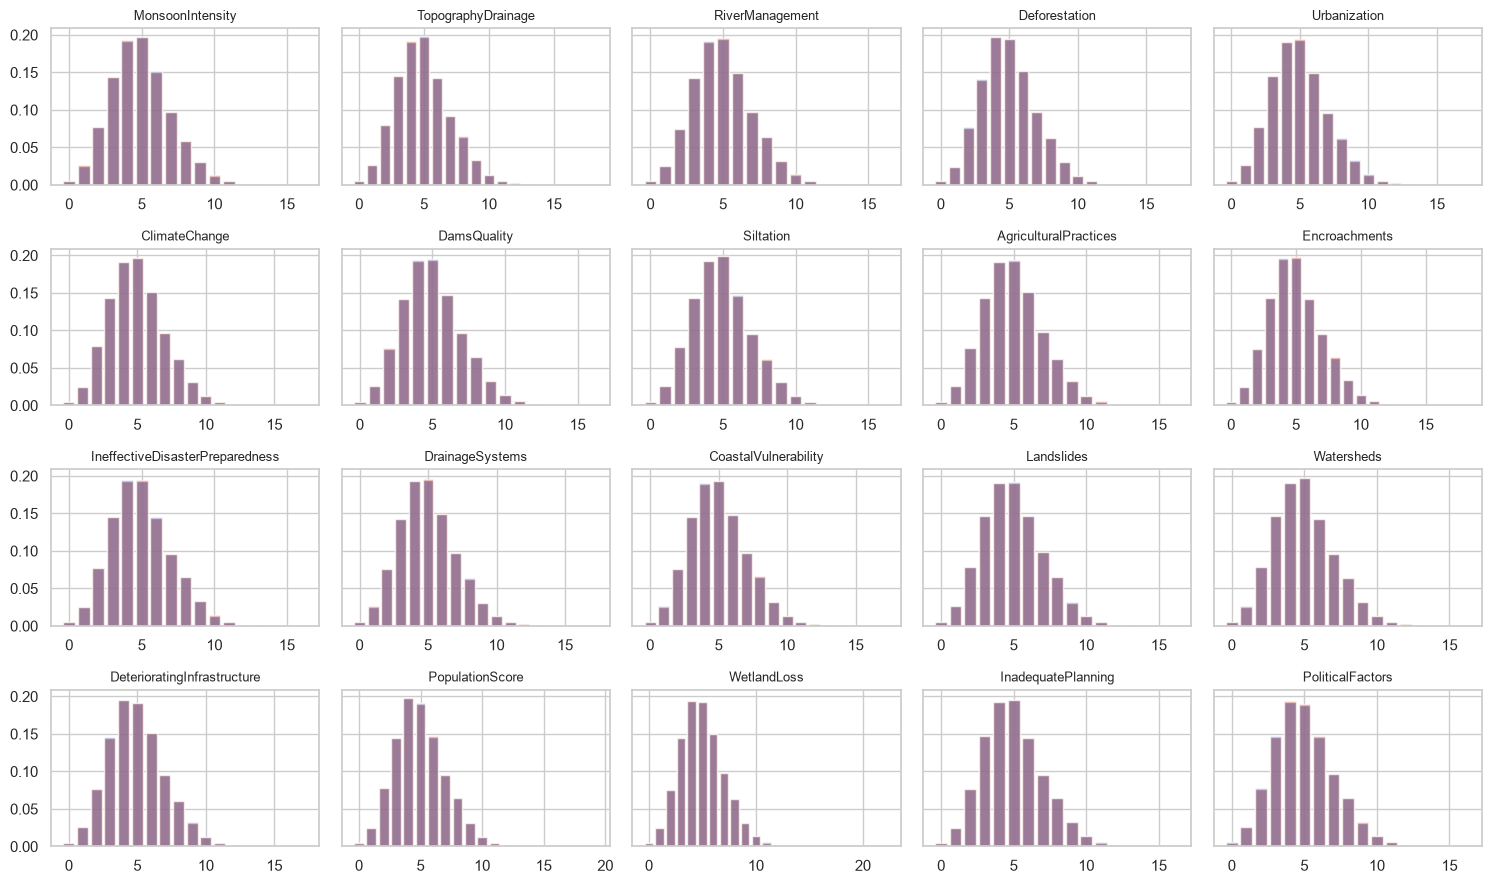

In [4]:
fig, axes = plt.subplots(4, 5, figsize=(15, 9), sharey=True)
for col, ax in zip(config.FEATURE_COLS, axes.ravel()):
    train_share = X[col].value_counts(normalize=True).sort_index()
    test_share = test_df[col].value_counts(normalize=True).sort_index()
    ax.bar(train_share.index, train_share.values, alpha=0.8)
    ax.bar(test_share.index, test_share.values, alpha=0.5)
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.show()

## 2. The key discovery: the original target is just a sum

The competition data was synthetically generated from a 50,000-row original dataset (`flood.csv`
in [naiyakhalid/flood-prediction-dataset](https://www.kaggle.com/datasets/naiyakhalid/flood-prediction-dataset)).
Checking the original directly:

In [5]:
original = pd.read_csv(config.ORIGINAL_CSV)
original_sum = original[config.FEATURE_COLS].sum(axis=1)
max_error = (original[config.TARGET_COL] - config.ORIGINAL_TARGET_PER_POINT * original_sum).abs().max()
print(f"original rows: {len(original):,}")
print(f"max |FloodProbability - 0.005 * sum| in the original: {max_error:.2e}")

original rows: 50,000
max |FloodProbability - 0.005 * sum| in the original: 1.11e-16


**In the original, `FloodProbability = 0.005 × sum`, exactly, for every row.** The competition's
synthetic generator perturbed the factor values, so in the competition data the same relationship
is buried in noise:

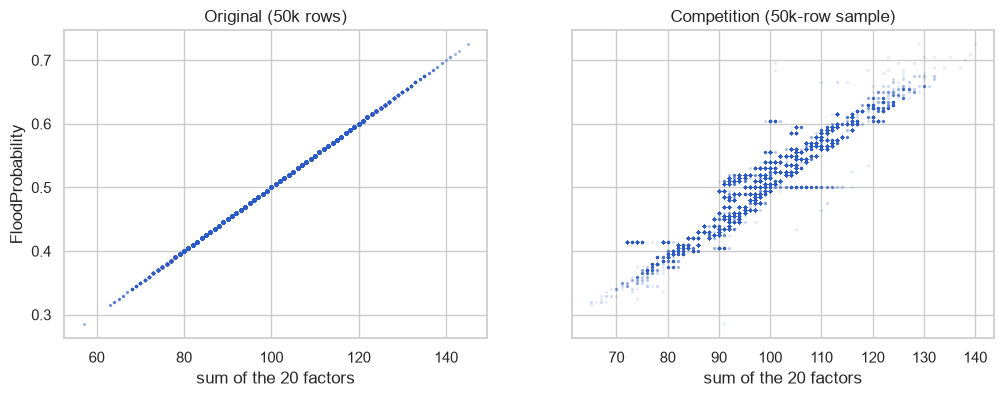

In [6]:
sample = train_df.sample(50_000, random_state=config.RANDOM_SEED)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].scatter(original_sum, original[config.TARGET_COL], s=2, alpha=0.3)
axes[0].set_title("Original (50k rows)")
axes[1].scatter(sample[config.FEATURE_COLS].sum(axis=1), sample[config.TARGET_COL], s=2, alpha=0.08)
axes[1].set_title("Competition (50k-row sample)")
for ax in axes:
    ax.set_xlabel("sum of the 20 factors")
axes[0].set_ylabel("FloodProbability")
plt.show()

So the real question this competition asks is: **given noisy factor values, recover the original
row sum.** Two consequences:

- Any single factor is a weak signal (all 20 correlate about equally, and weakly, with the target),
  while their sum is strong.
- The useful features describe the *whole row*: its sum, spread, shape, and sorted values — which
  help a model judge how much a row was perturbed.

In [7]:
correlations = sample[config.FEATURE_COLS].corrwith(sample[config.TARGET_COL])
row_sum_corr = sample[config.FEATURE_COLS].sum(axis=1).corr(sample[config.TARGET_COL])
print(f"single-factor correlations: {correlations.min():.3f} to {correlations.max():.3f}")
print(f"row-sum correlation:        {row_sum_corr:.3f}")

single-factor correlations: 0.174 to 0.194
row-sum correlation:        0.920


How far is the competition target from the original formula, in "points" (units of 0.005)? The
deviation is broad and roughly unbiased — this noise is what the models have to see through.

count    1.11796e+06
mean     2.10784e+00
std      4.15950e+00
min     -3.70000e+01
25%     -1.00000e+00
50%      2.00000e+00
75%      5.00000e+00
max      4.50000e+01
dtype: float64


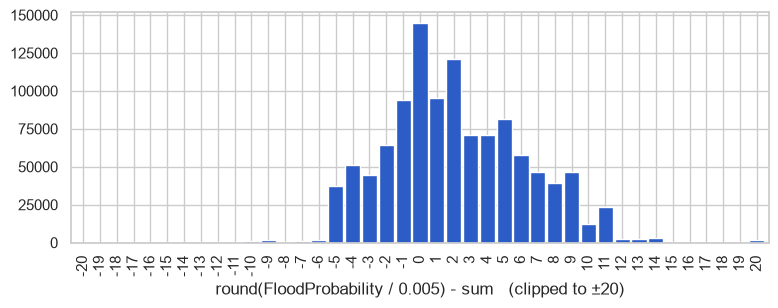

In [8]:
deviation_points = np.round(y / 0.005).astype(int) - X.sum(axis=1)
print(deviation_points.describe())
deviation_points.clip(-20, 20).value_counts().sort_index().plot.bar(figsize=(9, 3), width=0.9)
plt.xlabel("round(FloodProbability / 0.005) - sum   (clipped to ±20)")
plt.show()

## 3. Feature engineering

`features.RowStatsFeatures` keeps the 20 raw factors and adds 11 row statistics plus the row's
values sorted ascending (`sorted_00` = smallest factor, `sorted_19` = largest). Everything it adds
is invariant to *which* factor holds which value — just like the sum.

In [9]:
engineered = features.RowStatsFeatures().fit_transform(X.head(3))
engineered[features.ROW_STAT_COLS + features.SORTED_COLS[:3] + features.SORTED_COLS[-3:]]

,row_sum,row_std,row_max,row_min,row_median,row_range,row_skew,row_kurtosis,row_n_unique,row_q25,row_q75,sorted_00,sorted_01,sorted_02,sorted_17,sorted_18,sorted_19
id,,,,,,,,,,,,,,,,,
0,94.0,1.70587,8.0,2.0,4.5,6.0,0.57726,-0.52186,7,3.0,5.25,2.0,3.0,3.0,7.0,8.0,8.0
1,94.0,2.23830,9.0,0.0,4.0,9.0,0.14834,-0.35840,9,3.0,6.25,0.0,2.0,3.0,8.0,8.0,9.0
2,99.0,1.88348,8.0,1.0,5.0,7.0,-0.40808,-0.74241,8,3.0,6.25,1.0,2.0,3.0,7.0,7.0,8.0


## 4. Model comparison

Five-fold CV on all 1.1M rows takes several minutes per boosted model, so this comparison uses a
200,000-row random subsample with 3-fold CV — enough to rank the models reliably. (The full-data
5-fold numbers come from `scripts/make_ensemble_submission.py`, section 6.)

In [10]:
subsample = train_df.sample(200_000, random_state=config.RANDOM_SEED)
X_sub, y_sub = data.split_features_target(subsample)

results = []
for name, factory in model.MODEL_FACTORIES.items():
    scores = model.cross_validate_pipeline(X_sub, y_sub, estimator=factory(), cv=3)
    results.append({"model": name, **scores})
    print(f"{name:<18} R² {scores['r2_mean']:.5f} (± {scores['r2_std']:.5f})")
comparison = pd.DataFrame(results).sort_values("r2_mean", ascending=False)
comparison

Linear Regression  R² 0.84471 (± 0.00138)


LightGBM           R² 0.86668 (± 0.00120)


XGBoost            R² 0.86740 (± 0.00124)


CatBoost           R² 0.86674 (± 0.00099)


,model,r2_mean,r2_std,rmse_mean,rmse_std
2,XGBoost,0.86740,0.00124,0.01855,0.00004
3,CatBoost,0.86674,0.00099,0.01860,0.00002
1,LightGBM,0.86668,0.00120,0.01860,0.00003
0,Linear Regression,0.84471,0.00138,0.02008,0.00005


Linear regression is a much stronger baseline than usual — the original target *is* linear in the
features — but the boosted trees beat it by using the row statistics non-linearly.

### The hyperparameter that mattered most: column sampling

Many tuned-for-Kaggle defaults sample half the columns per tree (`colsample_bytree=0.5`). Here that
hurts: a tree that can't see `row_sum` has to approximate it from fragments. Same LightGBM, same
subsample, only column sampling changed:

In [11]:
from lightgbm import LGBMRegressor

colsample_results = {}
for colsample in (0.5, 1.0):
    estimator = model.lightgbm_estimator().set_params(colsample_bytree=colsample)
    scores = model.cross_validate_pipeline(X_sub, y_sub, estimator=estimator, cv=3)
    colsample_results[colsample] = scores["r2_mean"]
    print(f"colsample_bytree={colsample}: R² {scores['r2_mean']:.5f}")
print(f"gain from seeing every column: {colsample_results[1.0] - colsample_results[0.5]:+.5f}")

colsample_bytree=0.5: R² 0.86627


colsample_bytree=1.0: R² 0.86668
gain from seeing every column: +0.00041


## 5. What the app model learned (SHAP)

The app model (`models/model.joblib`, built by `scripts/train.py`) is a single LightGBM pipeline —
explainable with exact tree SHAP.

In [12]:
pipeline = model.load_pipeline()
explanation, X_transformed = interpretability.compute_shap_values(pipeline, X, max_samples=2_000)
interpretability.top_shap_features(explanation, top_n=10)

,feature,mean_abs_shap
0,row_sum,0.03777
1,row_max,0.00038
2,row_std,0.00038
3,row_skew,0.00020
4,sorted_18,0.00015
5,row_range,0.00013
6,row_min,0.00010
7,MonsoonIntensity,0.00007
8,sorted_17,0.00007
9,row_kurtosis,0.00007


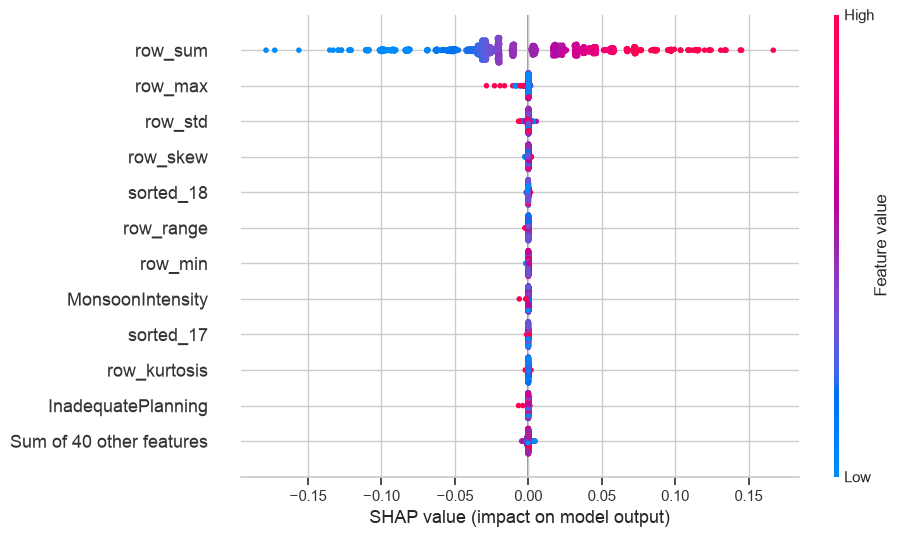

In [13]:
import shap

shap.plots.beeswarm(explanation, max_display=12, show=False)
plt.gcf().set_size_inches(9, 6)
plt.show()

`row_sum` dominates, followed by the sorted values and spread statistics; the named factors barely
register individually. That is the honest answer for this data — the target is (originally) a plain
sum, so no single factor matters more than another.

## 6. The leaderboard blend

`scripts/make_ensemble_submission.py` trains LightGBM, XGBoost, and CatBoost with 5-fold CV on all
1.1M rows, then learns non-negative blend weights on their out-of-fold predictions. Its saved
predictions are loaded here rather than retrained (~30 minutes).

In [14]:
saved = np.load(config.ENSEMBLE_PREDICTIONS_PATH)
members = list(saved["members"])
oof = {name: saved[f"oof_{name}"] for name in members}
blend_rows = [{"model": name, "OOF R²": r2_score(saved["y"], oof[name]), "weight": w}
              for name, w in zip(members, saved["weights"])]
blend_rows.append({"model": "Blend", "OOF R²": r2_score(saved["y"], model.blend(oof, saved["weights"])), "weight": 1.0})
pd.DataFrame(blend_rows)

,model,OOF R²,weight
0,LightGBM,0.86941,0.52737
1,XGBoost,0.86936,0.29384
2,CatBoost,0.86914,0.17879
3,Blend,0.86943,1.00000


## 7. Where would it have ranked?

The competition closed on 31 May 2024, so submissions now are *late*: scored, but not placed.
`leaderboard.would_rank` places each score against the frozen final leaderboards. Ties are common —
dozens of teams share each 5-decimal score near the top — so the rank is a range.

In [15]:
rows = []
for entry in leaderboard.SUBMISSION_HISTORY:
    private, public = leaderboard.would_rank(entry["private"], entry["public"])
    rows.append({"step": entry["step"], "OOF R²": entry["oof_r2"], "public": entry["public"],
                 "private": entry["private"],
                 "private rank": f"#{private.rank_best}-{private.rank_worst}",
                 "top %": round(private.percentile, 1)})
pd.DataFrame(rows)

,step,OOF R²,public,private,private rank,top %
0,"v1: LightGBM + XGBoost + CatBoost, plain average",0.86916,0.86909,0.86870,#535-547,19.1
1,"v2: same three models, tuned, NNLS-weighted blend",0.86940,0.86931,0.86893,#207-228,7.4
2,v3: v2 with 7 folds x 2 seeds,0.86943,0.86933,0.86893,#207-228,7.4


In [16]:
private_scores = leaderboard.load_scores(leaderboard.PRIVATE_LEADERBOARD_CSV)
for rank in (1, 10, 50, 100, 500):
    print(f"private rank {rank:>3}: {private_scores.iloc[rank - 1]:.5f}")

private rank   1: 0.86905
private rank  10: 0.86900
private rank  50: 0.86899
private rank 100: 0.86898
private rank 500: 0.86872


## 8. Takeaways

- **Find the generating process first.** The single biggest insight came from checking the original
  dataset, not from modeling: the target is a sum, so the features should describe the row as a whole.
- **Column sampling matters more than model choice.** With the signal concentrated in a few
  row-level features, every tree needs to see them all.
- **The leaderboard top is extremely tight.** The R² gaps between leaderboard tiers are in the fourth
  decimal place; out-of-fold scores, not single holdouts, are the only reliable way to compare changes
  that small.